In [1]:
%matplotlib inline
import numpy as np
import scipy
from scipy.sparse import coo_matrix, csr_matrix, csc_matrix, block_diag, identity, hstack
import matplotlib.pyplot as plt
from pyiga import assemble, bspline, vform, geometry,vis, solvers, utils, topology, algebra, quadrature
#from sksparse.cholmod import cholesky
from pyiga import adaptive as adap
import itertools
import time
import statistics as st
from pyiga import algebra_cy, assemble_cy

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)
np.set_printoptions(formatter={'float_kind':"{:.3f}".format})

In [2]:
def C1_coupling(kvs1, geo1, bdspec1, kvs2, geo2, bdspec2, flip=None):
        
    #[(ax1, sd1)], [(ax2, sd2)] = bdspec1, bdspec2
    ax1, sd1 = bspline._parse_bdspec(bdspec1,2)[0]
    ax2, sd2 = bspline._parse_bdspec(bdspec2,2)[0]
    #((kvs1, geo1),_), ((kvs2, geo2),_) = self.mesh.patches[p1], self.mesh.patches[p2]
    sup1, sup2 = geo1.support, geo2.support
    dim=len(kvs1)
    if flip is None:
        flip=(dim-1)*(False,)
 
    bkv1, bkv2 = assemble.boundary_kv(kvs1, bdspec1), assemble.boundary_kv(kvs2, bdspec2)
    dofs1, dofs2 = assemble._boundary_dofs(kvs1, bdspec1, ravel = True, layer=1), assemble._boundary_dofs(kvs2, bdspec2, ravel = True, flip=flip, layer=1)
    G = tuple(kv.greville() for kv in kvs2)
    G2 = G[:ax2] + (np.array([sup2[ax2][0] if sd2==0 else sup2[ax2][-1]]),) + G[ax2+1:]
    G1 = G[:ax2] + G[ax2+1:]
    G1 = G1[:ax1] + (np.array([sup1[ax1][0] if sd1==0 else sup1[ax1][-1]]),) + G1[ax1:] #still need to add flip

    M=tuple(len(g) for g in G2)
    m=np.prod(M)
    n1,n2=len(dofs1), len(dofs2)
        
    C1, D1 = bspline.collocation_derivs_tp(kvs1, G1, derivs=1)
    C2, D2 = bspline.collocation_derivs_tp(kvs2, G2, derivs=1)
    
    C1, C2 = C1[0].tocsr()[:,dofs1], C2[0].tocsr()[:,dofs2]
    for i in range(dim):
        D1[i], D2[i] = D1[i].tocsr()[:,dofs1], D2[i].tocsr()[:,dofs2]
    N2=geo2.boundary(bdspec2).grid_outer_normal(G2[:ax2]+G2[ax2+1:]).reshape(m,dim)

    J1=geo1.grid_jacobian(G1).reshape(m,dim,dim)
    J2=geo2.grid_jacobian(G2).reshape(m,dim,dim)
        
    invJ1=np.array([np.linalg.inv(jac) for jac in J1[:]])
    invJ2=np.array([np.linalg.inv(jac) for jac in J2[:]])

    NC1=scipy.sparse.csr_matrix((m, n1))
    for i in range(dim):
        NC1_ = scipy.sparse.csr_matrix((m, n1))
        for j in range(dim):
            NC1_ += scipy.sparse.spdiags(invJ1[:,i,j], 0, m, m)*D1[dim-1-j]
        NC1 += scipy.sparse.spdiags(N2[:,i], 0, m, m)*NC1_
            
    NC2=scipy.sparse.csr_matrix((m, n2))
    for i in range(dim):
        NC2_ = scipy.sparse.csr_matrix((m, n2))
        for j in range(dim):
            NC2_ += scipy.sparse.spdiags(invJ2[:,i,j], 0, m, m)*D2[dim-1-j]
        NC2 += scipy.sparse.spdiags(N2[:,i], 0, m, m)*NC2_
            
    A = scipy.sparse.vstack([C1, NC1])
    B = scipy.sparse.vstack([C2, NC2])
    P = scipy.sparse.linalg.spsolve(B,A.toarray())
    # prune matrix
    P[np.abs(P) < 1e-15] = 0.0
    P = coo_matrix(P)

    data = np.concatenate([-P.data, np.ones(len(dofs2))])
    I = np.concatenate([P.row, np.arange(len(dofs2))])
    J = np.concatenate([dofs1[P.col],dofs2 + bspline.numdofs(kvs1)])

    return scipy.sparse.csr_matrix((data,(I,J)),(len(dofs2), bspline.numdofs(kvs1)+bspline.numdofs(kvs2)))

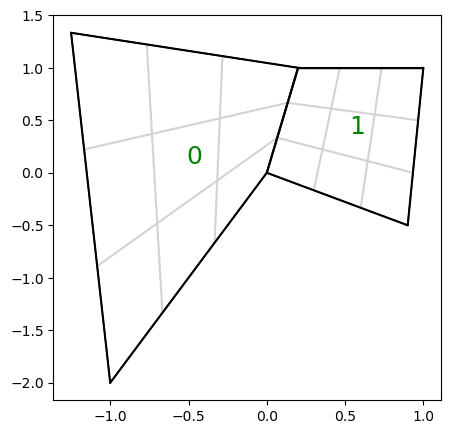

In [95]:
deg, N = 2,3

geo1 = geometry.Quad(np.array([[0,0],[-1,-2],[1/5,1],[-5/4,4/3]]).T)
geo2 = geometry.Quad(np.array([[0,0],[9/10,-1/2],[1/5,1],[1,1]]).T)

#geo1=geometry.unit_square()
#geo2=geometry.unit_square().translate((1,0))
kvs = 2 * (bspline.make_knots(deg, 0.0, 1.0, N),)

M = topology.MultiPatch([(kvs,geo1),(kvs,geo2)])
MP = assemble.MultiBasis(M, automatch=1)
M.plotmesh(knots=1,patch_idx=1)

In [105]:
MP.mesh.patches[0][0][1]

In [96]:
C = C1_coupling(kvs,geo1,"right", kvs, geo2, "left")

In [97]:
Basis, Constr = algebra_cy.pyx_compute_basis(*C.shape,C,maxiter=50,switch=1)

5 0 5
0 0 5
0 0 5
0 0 0


In [100]:
Basis.toarray()

array([[1.000, 0.000, 0.000, ..., 0.000, 0.000, 0.000],
       [0.000, 1.000, 0.000, ..., 0.000, 0.000, 0.000],
       [0.000, 0.000, 1.000, ..., 0.000, 0.000, 0.000],
       ...,
       [0.000, 0.000, 0.000, ..., 1.000, 0.000, 0.000],
       [0.000, 0.000, 0.000, ..., 0.000, 1.000, 0.000],
       [0.000, 0.000, 0.000, ..., 0.000, 0.000, 1.000]], shape=(50, 40))

In [93]:
Basis@np.repeat(1,2380)

array([1.000, 1.000, 1.000, ..., 1.000, 1.000, 1.000], shape=(2450,))

In [94]:
abs(C@Basis).data.max()

ValueError: zero-size array to reduction operation maximum which has no identity